# Import libraries & functions

In [63]:
import matplotlib
matplotlib.rc('image', cmap='gray')
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import pandas as pd
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
import cv2
import seaborn as sns
from skimage.morphology import binary_opening,binary_closing,disk
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from intensity_utils import postprocess_mask,predict_nucleus_cytoplasm_masks,calc_nc_ratio_from_image,get_nucleus_cytoplasm_masks,calculate_true_NC_ratios,plot_pred_vs_gt,plot_segmentation_breakdown,plot_confusion_analysis,get_nc_ratio_from_mask, mean_absolute_error


# Load Data

In [2]:
urothelial_cells=pd.read_pickle("urothelial_cell_toy_data.pkl")
images=np.transpose(urothelial_cells["X"].numpy()*255,(0,2,3,1)).astype(np.uint8)
labels=urothelial_cells["y"]
no_nucleus=(labels==2).sum(axis=(1,2))==0
images=images[~no_nucleus]
labels=labels[~no_nucleus]
images_gray=np.array([rgb2gray(each_image/255.) for each_image in images])
    

In [3]:
X_train_val,X_test,Y_train_val,Y_test=train_test_split(images_gray,labels,test_size=0.2,stratify=labels.mean((1,2))>=np.median(labels.mean((1,2))),random_state=42)
X_train,X_val,Y_train,Y_val=train_test_split(X_train_val,Y_train_val,test_size=0.2,stratify=Y_train_val.mean((1,2))>=np.median(Y_train_val.mean((1,2))),random_state=42)

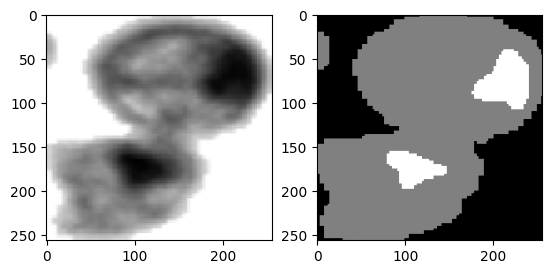

In [4]:
idx=2
plt.subplot(1,2,1)
plt.imshow(X_train[idx])
plt.subplot(1,2,2)
plt.imshow(Y_train[idx])

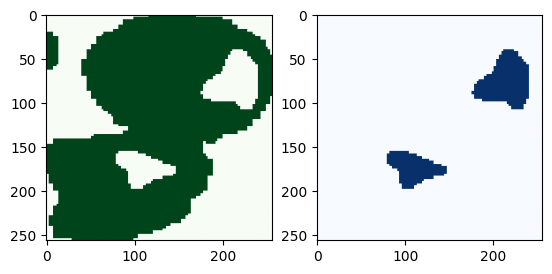

In [5]:
plt.subplot(121)
plt.imshow(Y_train[idx]==1,cmap="Greens")
plt.subplot(122)
plt.imshow(Y_train[idx]==2,cmap="Blues")

## Calculate True NC Ratios

In [6]:
nc_ratio_train_true,nc_ratio_val_true,nc_ratio_test_true=calculate_true_NC_ratios(Y_train,Y_val,Y_test)

## Practice Selecting Thresholds for NC Ratio Calculation

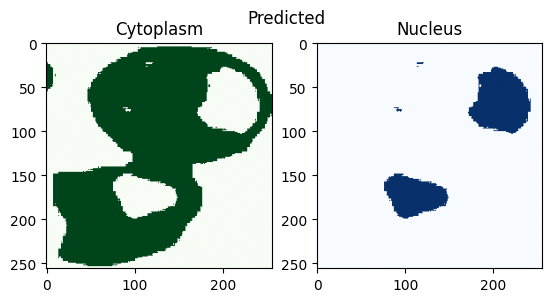

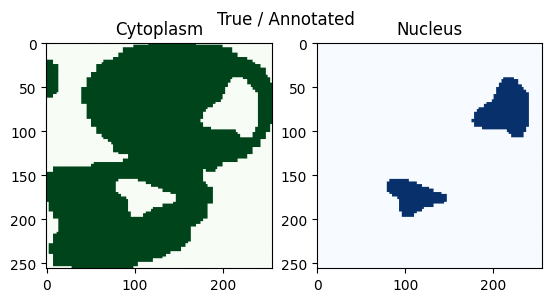

In [7]:
nucleus_threshold=0.4
cytoplasm_threshold=0.8

nucleus_mask,cytoplasm_mask,y_pred=predict_nucleus_cytoplasm_masks(X_train[idx],nucleus_threshold,cytoplasm_threshold,postprocess=False,return_pred=True)

nucleus_gt,cytoplasm_gt=get_nucleus_cytoplasm_masks(Y_train[idx])

plot_pred_vs_gt(cytoplasm_mask, nucleus_mask,
                cytoplasm_gt, nucleus_gt)

Try a new threshold:

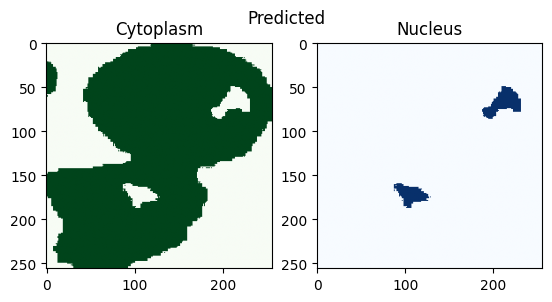

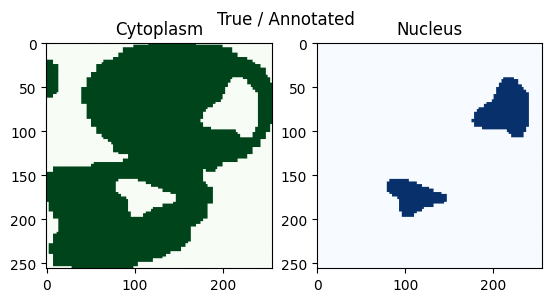

In [8]:
nucleus_threshold=0.2
cytoplasm_threshold=0.9

nucleus_mask,cytoplasm_mask,y_pred=predict_nucleus_cytoplasm_masks(X_train[idx],nucleus_threshold,cytoplasm_threshold,postprocess=False,return_pred=True)

nucleus_gt,cytoplasm_gt=get_nucleus_cytoplasm_masks(Y_train[idx])

plot_pred_vs_gt(cytoplasm_mask, nucleus_mask,
                cytoplasm_gt, nucleus_gt)

## Measure pixelwise performance

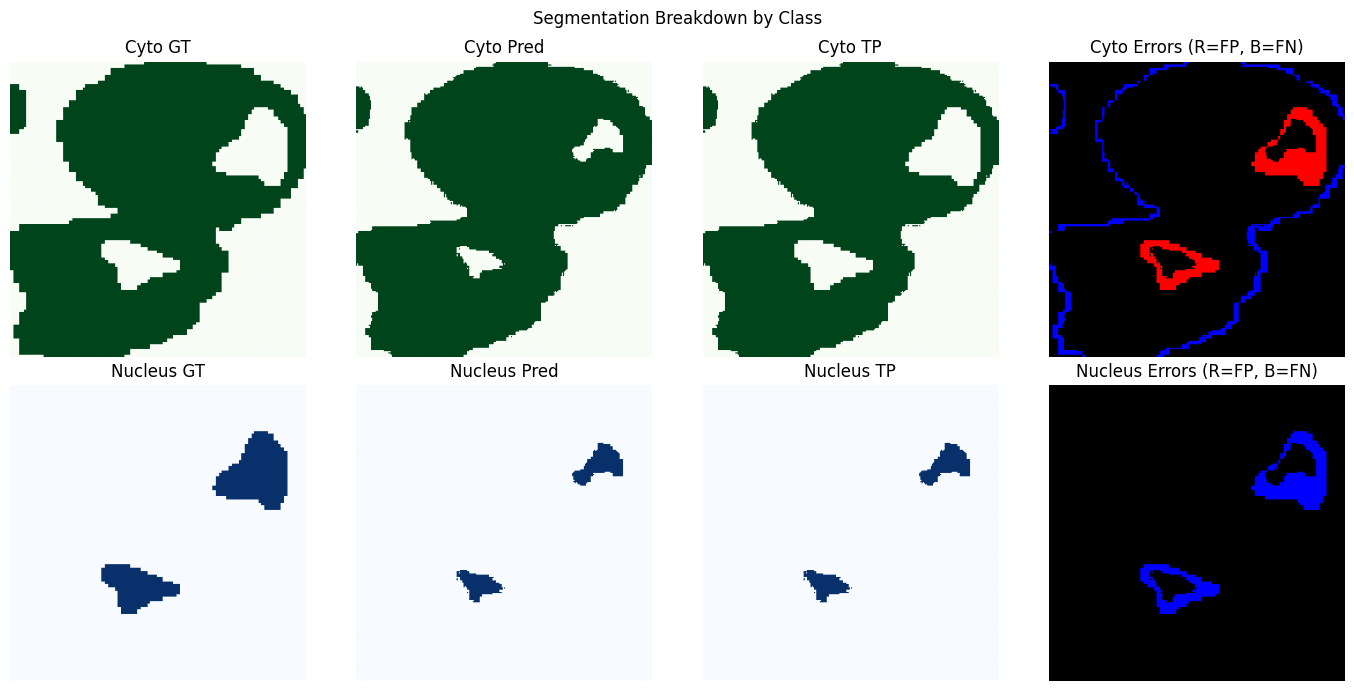

In [9]:
plot_segmentation_breakdown(cytoplasm_mask, nucleus_mask,
                            cytoplasm_gt, nucleus_gt)

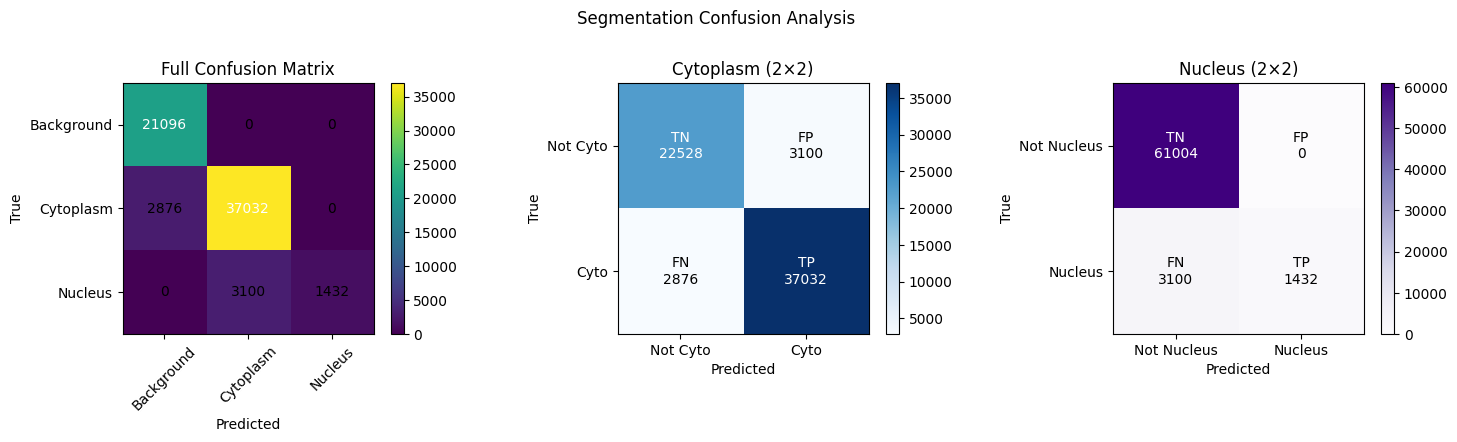

In [10]:
plot_confusion_analysis(Y_train[idx], y_pred)

In [11]:
y_true=Y_train[idx].flatten()
print(classification_report(y_true,y_pred.flatten(),target_names=["Background","Cytoplasm","Nucleus"]))

              precision    recall  f1-score   support

  Background       0.88      1.00      0.94     21096
   Cytoplasm       0.92      0.93      0.93     39908
     Nucleus       1.00      0.32      0.48      4532

    accuracy                           0.91     65536
   macro avg       0.93      0.75      0.78     65536
weighted avg       0.91      0.91      0.90     65536



In [12]:
y_true=Y_train[idx].flatten()
nucleus_thresholds=np.arange(0,1.1,0.1)
cytoplasm_thresholds=np.arange(0,1.1,0.1)
results_list=[]
for nucleus_threshold in nucleus_thresholds:
    for cytoplasm_threshold in cytoplasm_thresholds:
        if nucleus_threshold<cytoplasm_threshold:
            nucleus_mask,cytoplasm_mask,y_pred=predict_nucleus_cytoplasm_masks(X_train[idx],nucleus_threshold,cytoplasm_threshold,postprocess=False,return_pred=True)
            results_list.append([round(nucleus_threshold,1),round(cytoplasm_threshold,1),round(f1_score(y_true,y_pred.flatten(),average="macro"),2)*100])
results_df=pd.DataFrame(results_list,columns=["nucleus_threshold","cytoplasm_threshold","F1 Score"])
results_df.sort_values("F1 Score",ascending=False).head(15)  

,nucleus_threshold,cytoplasm_threshold,F1 Score
32,0.3,0.9,90.0
38,0.4,0.9,89.0
31,0.3,0.8,87.0
37,0.4,0.8,85.0
30,0.3,0.7,81.0
36,0.4,0.7,79.0
25,0.2,0.9,78.0
43,0.5,0.9,77.0
24,0.2,0.8,74.0
42,0.5,0.8,73.0


## Try on new image

In [13]:
top_nucleus_threshold,top_cytoplasm_threshold=results_df.sort_values("F1 Score",ascending=False).iloc[0][["nucleus_threshold","cytoplasm_threshold"]]

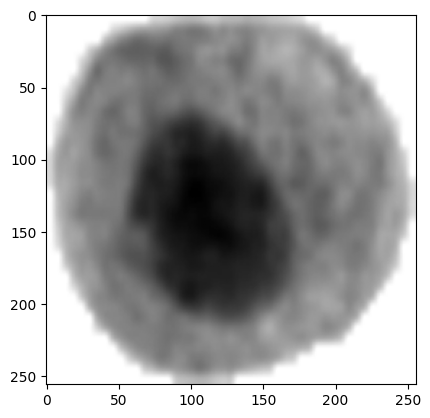

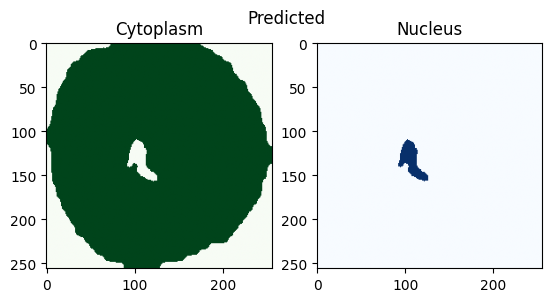

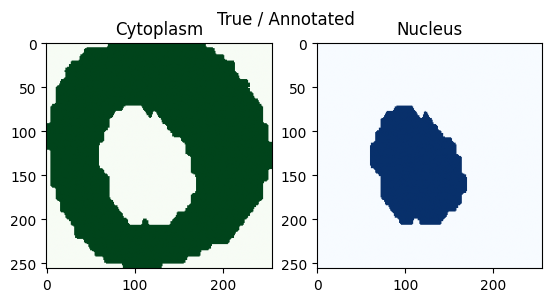

In [14]:
idx_new=99
nucleus_mask,cytoplasm_mask,y_pred=predict_nucleus_cytoplasm_masks(X_train[idx_new],top_nucleus_threshold,top_cytoplasm_threshold,postprocess=False,return_pred=True)

nucleus_gt,cytoplasm_gt=get_nucleus_cytoplasm_masks(Y_train[idx_new])
plt.figure()
plt.imshow(X_train[idx_new])

plot_pred_vs_gt(cytoplasm_mask, nucleus_mask,
                cytoplasm_gt, nucleus_gt)

In [15]:
y_true=Y_train[idx_new].flatten()
print(classification_report(y_true,y_pred.flatten(),target_names=["Background","Cytoplasm","Nucleus"]))

              precision    recall  f1-score   support

  Background       0.91      1.00      0.95     12780
   Cytoplasm       0.80      0.97      0.88     42045
     Nucleus       1.00      0.07      0.13     10711

    accuracy                           0.83     65536
   macro avg       0.90      0.68      0.65     65536
weighted avg       0.86      0.83      0.77     65536



## Clean up the mask with morphological operations

/Users/joshualevy/Documents/Classes/AICampus/2026/Cedars_AI_Campus_Tutorials-main/Project3/intensity_utils.py:18: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask=binary_opening(mask,disk(opening_size))
/Users/joshualevy/Documents/Classes/AICampus/2026/Cedars_AI_Campus_Tutorials-main/Project3/intensity_utils.py:19: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask=binary_closing(mask,disk(closing_size))
/Users/joshualevy/Documents/Classes/AICampus/2026/Cedars_AI_Campus_Tutorials-main/Project3/intensity_utils.py:18: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask=binary_opening(mask,disk(opening_size))
/Users/joshualevy/Documents/Classes/AICampus/2026/Cedars_AI_Campus_Tutorials-main/Pro

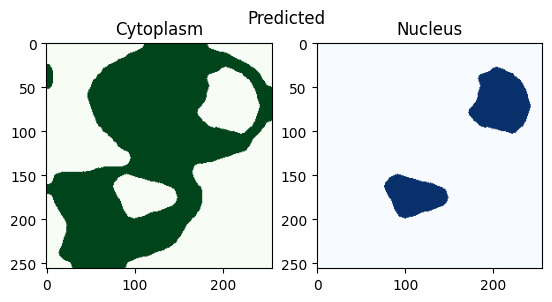

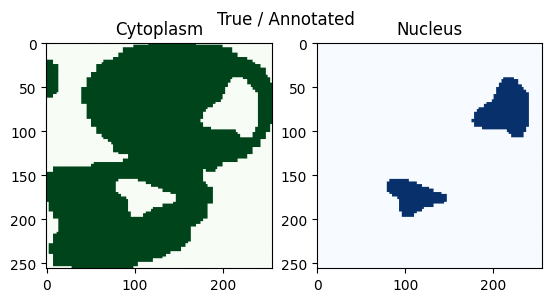

In [16]:
nucleus_threshold=0.4
cytoplasm_threshold=0.8

nucleus_mask,cytoplasm_mask,y_pred=predict_nucleus_cytoplasm_masks(X_train[idx],nucleus_threshold,cytoplasm_threshold,postprocess=True,return_pred=True)

nucleus_gt,cytoplasm_gt=get_nucleus_cytoplasm_masks(Y_train[idx])

plot_pred_vs_gt(cytoplasm_mask, nucleus_mask,
                cytoplasm_gt, nucleus_gt)

## Calculate NC Ratio

In [101]:
get_nc_ratio_from_mask(y_true),get_nc_ratio_from_mask(y_pred),calc_nc_ratio_from_image(X_train[idx],nucleus_threshold,cytoplasm_threshold,postprocess=True)


(np.float64(0.2030290393509743),
 np.float64(0.15661378386731226),
 np.float64(0.15661378386731226))

## Run function across cohort

In [23]:
thresholds=(nucleus_threshold,cytoplasm_threshold)
nc_ratio_test_pred=np.array([calc_nc_ratio_from_image(each_image,nucleus_threshold,cytoplasm_threshold) for each_image in X_test])
stat=float(spearmanr(nc_ratio_test_pred,nc_ratio_test_true,nan_policy="omit")[0])
stat,mean_absolute_error(nc_ratio_test_true,nc_ratio_test_pred)

(0.6860323886639675, 0.16835477260459336)

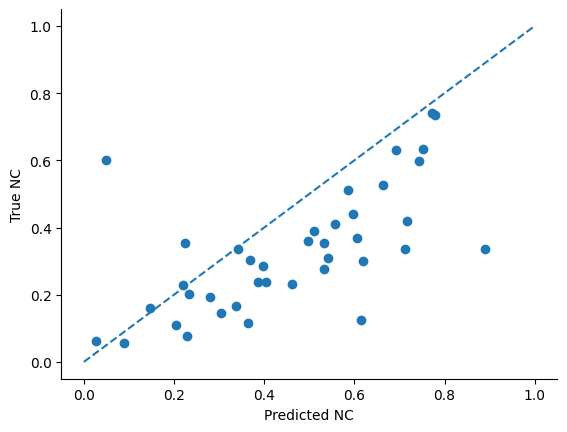

In [24]:
plt.scatter(nc_ratio_test_pred,nc_ratio_test_true)
plt.plot([0,1],[0,1],ls="--")
plt.xlabel("Predicted NC")
plt.ylabel("True NC")
sns.despine()

## Advanced Approach: Optimize Thresholds

In [60]:
# Comment out and install scikit-optimize optuna if you don't have it
# ! pip install scikit-optimize optuna

In [91]:
import optuna
optuna.logging.set_verbosity(optuna.logging.CRITICAL)
import warnings
import numpy as np
from functools import partial
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

def callback(study, trial, metric):
    best = study.best_trial
    val = -best.value if metric == 'spearman' else best.value
    print(f"Iter {len(study.trials)} | Best: {val:.4f} | x={sorted(best.params.values())}")

metric_dict = dict(
    spearman=lambda x, y: spearmanr(x, y, nan_policy="omit")[0],
    mae=lambda x, y: -mean_absolute_error(x, y)
)

def loss_func(thresholds, metric="spearman"):
    # thresholds = sorted(thresholds)

    nc_ratio_train_pred = np.vectorize(
        lambda x: calc_nc_ratio_from_image(x, *thresholds, postprocess=False),
        signature='(w,h)->()'
    )(X_train)

    if np.sum(~np.isnan(nc_ratio_train_pred)) < 3:
        return 1

    stat = metric_dict[metric](nc_ratio_train_true, nc_ratio_train_pred)

    if np.isnan(stat) and metric == "spearman":
        return 0
    elif np.isnan(stat) and metric == "mae":
        return 1
    
    return -stat

def make_objective(metric):
    def objective(trial):
        t1 = trial.suggest_float("threshold1", 0, 0.99) # , step=0.0001
        t2 = trial.suggest_float("threshold2", t1, 0.99) # , step=0.0001
        return loss_func([t1, t2], metric=metric)
    return objective

space = [
    (0, 0.99),  # threshold1
    (0, 0.99)   # threshold2
]


metric = "mae"

sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(direction="minimize",sampler=sampler)

study.optimize(
    make_objective(metric),
    n_trials=150,
    n_jobs=4,
    
    callbacks=[lambda study, trial: callback(study, trial, metric)]
)

class Result:
    pass

res = Result()
res.x = list(study.best_trial.params.values())
res.fun = study.best_value
res.x_iters = [list(t.params.values()) for t in study.trials]
res.func_vals = np.array([t.value for t in study.trials])

print("\nFinal result:")
print("Best x:", sorted(res.x))
print("Best value:", (-res.fun if metric == "spearman" else res.fun))

Iter 4 | Best: 0.5394 | x=[0.5793327370445122, 0.6589394310462935]
Iter 5 | Best: 0.4648 | x=[0.5416181696844405, 0.6630651482142651]
Iter 6 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 6 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 8 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 8 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 10 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 11 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 12 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 13 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 14 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 15 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 16 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 17 | Best: 0.1226 | x=[0.3240078451806873, 0.8267059257882764]
Iter 18 | Best: 0.1226 | x=[0.3240078451806873, 0.8267

In [92]:
final_thresholds=sorted(res.x_iters[res.func_vals.argmin()])
pd.to_pickle(final_thresholds,"final_thresholds.pkl")

In [93]:
nc_ratio_test_pred=np.vectorize(lambda x: calc_nc_ratio_from_image(x,*final_thresholds,postprocess=True),signature='(w,h)->()')(X_test)
spearmanr(nc_ratio_test_pred,nc_ratio_test_true,nan_policy="omit")[0],np.abs(nc_ratio_test_pred-nc_ratio_test_true).mean()

(np.float64(0.7038817762949379), np.float64(0.10673102119426453))

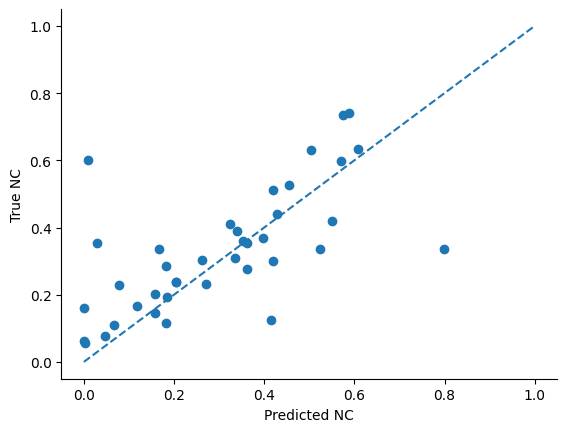

In [94]:
plt.scatter(nc_ratio_test_pred,nc_ratio_test_true)
plt.plot([0,1],[0,1],ls="--")
plt.xlabel("Predicted NC")
plt.ylabel("True NC")
sns.despine()

In [95]:
# separate optimization with skopt

In [96]:
from scipy.optimize import minimize
from skopt import gp_minimize
from skopt.space import Real
import warnings
import numpy as np
from functools import partial
warnings.filterwarnings("ignore")
def callback(res,metric):
    print(f"Iter {len(res.x_iters)} | Best: {(-res.fun if metric=='spearman' else res.fun):.4f} | x={sorted(res.x)}")

metric_dict=dict(spearman=lambda x,y: spearmanr(x,y,nan_policy="omit")[0],
                mae=lambda x,y: -mean_absolute_error(x,y))

def loss_func(thresholds,metric="spearman"):
    thresholds=sorted(thresholds)
    nc_ratio_train_pred=np.vectorize(lambda x: calc_nc_ratio_from_image(x,*thresholds,postprocess=False),signature='(w,h)->()')(X_train)
    if np.sum(~np.isnan(nc_ratio_train_pred))<3: return 1
    stat=metric_dict[metric](nc_ratio_train_true,nc_ratio_train_pred)
    if np.isnan(stat) and metric=="spearman": return 0
    elif np.isnan(stat) and metric=="mae": return 1
    return -stat


space = [
    Real(0, 0.99, name='threshold1'),
    Real(0, 0.99, name='threshold2')
]

metric="mae"
# Perform the optimization
res = gp_minimize(lambda x: loss_func(x,metric=metric), space, x0=(0.2,0.8), n_calls=50, acq_optimizer="lbfgs", acq_func="EI", noise=1e-1, n_restarts_optimizer=15, random_state=0, n_jobs=4, callback=[lambda res: callback(res,metric)], verbose=False)


Iter 1 | Best: 0.1645 | x=[0.2, 0.8]
Iter 2 | Best: 0.1645 | x=[0.2, 0.8]
Iter 3 | Best: 0.1645 | x=[0.2, 0.8]
Iter 4 | Best: 0.1645 | x=[0.2, 0.8]
Iter 5 | Best: 0.1645 | x=[0.2, 0.8]
Iter 6 | Best: 0.1645 | x=[0.2, 0.8]
Iter 7 | Best: 0.1645 | x=[0.2, 0.8]
Iter 8 | Best: 0.1537 | x=[0.3888569481398215, 0.827717975902004]
Iter 9 | Best: 0.1537 | x=[0.3888569481398215, 0.827717975902004]
Iter 10 | Best: 0.1225 | x=[0.36455912444214256, 0.9475836073635161]
Iter 11 | Best: 0.1225 | x=[0.36455912444214256, 0.9475836073635161]
Iter 12 | Best: 0.1225 | x=[0.36455912444214256, 0.9475836073635161]
Iter 13 | Best: 0.1178 | x=[0.30139596333078994, 0.99]
Iter 14 | Best: 0.1178 | x=[0.30139596333078994, 0.99]
Iter 15 | Best: 0.1161 | x=[0.3132706183727416, 0.99]
Iter 16 | Best: 0.1161 | x=[0.3132706183727416, 0.99]
Iter 17 | Best: 0.1161 | x=[0.3132706183727416, 0.99]
Iter 18 | Best: 0.1161 | x=[0.3132706183727416, 0.99]
Iter 19 | Best: 0.1154 | x=[0.34709494527458384, 0.99]
Iter 20 | Best: 0.115